# **AI-Based Battery State Estimation Algorithm Research**

**Project Overview:**

This notebook implements various machine learning algorithms for battery State of Health (SoH) estimation using the NASA Battery Aging Dataset. The research focuses on developing robust estimation algorithms through advanced feature engineering and comparative analysis of multiple ML approaches.

---

### **1. Package Loading and Environment Setup**

#### **1.1 Import Core Libraries**

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# File handling and utilities
import os
import glob
from pathlib import Path

### **2. Data Loading and Initial Inspectiion**

#### **2.1 Dataset Path Configuration**

In [2]:
# Define data paths
BASE_PATH = "cleaned_dataset"
METADATA_PATH = os.path.join(BASE_PATH, "metadata.csv")
DATA_FOLDER = os.path.join(BASE_PATH, "data")

# Verify paths exist
if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Metadata file not found at: {METADATA_PATH}")
if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder not found at: {DATA_FOLDER}")

print(f"Base path: {BASE_PATH}")
print(f"Metadata path: {METADATA_PATH}")
print(f"Data folder: {DATA_FOLDER}")

Base path: cleaned_dataset
Metadata path: cleaned_dataset/metadata.csv
Data folder: cleaned_dataset/data


#### **2.2 Metadata Loading and Inspection**

In [3]:
# Load metadata
metadata = pd.read_csv(METADATA_PATH)

print("Metadata Dataset Information (Before Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\n" + "=" * 50)

# Display first few rows of metadata
print("First few rows of metadata:")
display(metadata.head())

Metadata Dataset Information (Before Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 3.35 MB

Column information:
type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

First few rows of metadata:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


#### **2.3 Data Type Conversion and Metadata Preprocessing**

In [4]:
# Convert numerical columns from object to appropriate types
def preprocess_metadata(df):
    """
    Preprocess metadata by converting data types and handling missing values
    """
    df = df.copy()
    
    # Convert Capacity, Re, Rct to numeric (they are stored as strings)
    numeric_columns = ['Capacity', 'Re', 'Rct']
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Apply preprocessing
metadata = preprocess_metadata(metadata)

print("Metadata Dataset Information (After Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\nMissing values:")
print(metadata.isnull().sum())

Metadata Dataset Information (After Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 2.55 MB

Column information:
type                    object
start_time              object
ambient_temperature      int64
battery_id              object
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Missing values:
type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4796
Re                     5618
Rct                    5618
dtype: int64


#### **2.4 Battery Identification and Data Overview**

In [5]:
# Identify unique batteries in the dataset
unique_batteries = metadata['battery_id'].unique()
print(f"Available batteries: {sorted(unique_batteries)}")
print(f"Total number of batteries: {len(unique_batteries)}")

# Analyze test types distribution
test_type_counts = metadata['type'].value_counts()
print(f"\nTest type distribution:")
print(test_type_counts)

# Battery-wise data distribution
battery_distribution = metadata.groupby('battery_id').agg({
    'type': 'count',
    'Capacity': lambda x: x.notna().sum(),
    'Re': lambda x: x.notna().sum(),
    'Rct': lambda x: x.notna().sum()
}).rename(columns={'type': 'total_cycles'})

print(f"\nBattery-wise data distribution:")
display(battery_distribution)

Available batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']
Total number of batteries: 34

Test type distribution:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Battery-wise data distribution:


,total_cycles,Capacity,Re,Rct
battery_id,,,,
B0005,616,168,278,278
B0006,616,168,278,278
B0007,616,168,278,278
B0018,319,132,53,53
B0025,80,28,21,21
B0026,80,28,21,21
B0027,80,28,21,21
B0028,80,28,21,21
B0029,97,40,17,17


#### **2.5 Sample Cycle Data Loading and Inspection**

In [6]:
# Load a sample cycle file to understand the structure
sample_file = os.path.join(DATA_FOLDER, "00001.csv")

if os.path.exists(sample_file):
    sample_cycle = pd.read_csv(sample_file)
    
    print("Sample Cycle Data Information:")
    print("=" * 40)
    print(f"Dataset shape: {sample_cycle.shape}")
    print(f"Memory usage: {sample_cycle.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print("\nColumn information:")
    print(sample_cycle.dtypes)
    
    print(f"\nFirst few rows of sample cycle data:")
    display(sample_cycle.head())
    
    print(f"\nBasic statistics:")
    display(sample_cycle.describe())
else:
    print(f"Sample file {sample_file} not found")

Sample Cycle Data Information:
Dataset shape: (490, 6)
Memory usage: 23.09 KB

Column information:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First few rows of sample cycle data:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625



Basic statistics:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,3.475266,-0.952767,8.272423,0.957153,2.817939,3205.134141
std,0.284626,0.201448,1.455269,0.202690,0.644985,1861.395346
min,2.470612,-1.001101,5.008084,0.000200,0.000000,0.000000
25%,3.336993,-0.995898,7.313213,1.000000,2.790500,1598.417750
50%,3.491946,-0.995207,8.184590,1.000000,2.945500,3200.492500
75%,3.655987,-0.994648,9.025544,1.000000,3.105750,4809.176250
max,4.246764,0.000252,12.376816,1.000000,4.262000,6436.141000


### **3. Data Preprocessing and Feature Engineering**

#### **3.1 Battery Selection and Filtering Strategy**

In [7]:
# Define batteries to exclude based on reference analysis
excluded_batteries = ['B0049', 'B0050', 'B0051', 'B0052']

# Filter metadata for valid batteries
valid_batteries = [b for b in unique_batteries if b not in excluded_batteries]
print(f"Valid batteries for analysis: {valid_batteries}")
print(f"Excluded batteries: {excluded_batteries}")

# Filter metadata for valid batteries only
filtered_metadata = metadata[metadata['battery_id'].isin(valid_batteries)].copy()
print(f"\nFiltered metadata shape: {filtered_metadata.shape}")

# Focus on discharge cycles for capacity calculation
discharge_metadata = filtered_metadata[filtered_metadata['type'] == 'discharge'].copy()
print(f"Discharge cycles available: {len(discharge_metadata)}")

# Battery-wise discharge cycle distribution
discharge_distribution = discharge_metadata.groupby('battery_id').size()
print(f"\nDischarge cycles per battery:")
print(discharge_distribution)

Valid batteries for analysis: ['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040', 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041', 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054', 'B0056', 'B0055']
Excluded batteries: ['B0049', 'B0050', 'B0051', 'B0052']

Filtered metadata shape: (7317, 10)
Discharge cycles available: 2694

Discharge cycles per battery:
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
B0025     28
B0026     28
B0027     28
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    197
B0034    197
B0036    197
B0038     47
B0039     47
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0053     56
B0054    103
B0055    102
B0056    102
dtype: int64


#### **3.2 Cycle Data Loading Function**

In [8]:
def load_cycle_data(filename, data_folder=DATA_FOLDER):
    """
    Load individual cycle data with error handling
    
    Parameters:
    -----------
    filename : str
        Filename of the cycle data
    data_folder : str
        Path to data folder
        
    Returns:
    --------
    pd.DataFrame or None
        Loaded cycle data or None if error
    """
    try:
        file_path = os.path.join(data_folder, filename)
        if not os.path.exists(file_path):
            print(f"Warning: File {filename} not found")
            return None
            
        cycle_data = pd.read_csv(file_path)
        
        # Verify expected columns are present
        expected_columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 
                          'Current_load', 'Voltage_load', 'Time']
        
        if not all(col in cycle_data.columns for col in expected_columns):
            print(f"Warning: Missing expected columns in {filename}")
            return None
            
        return cycle_data
        
    except Exception as e:
        print(f"Error loading {filename}: {str(e)}")
        return None

# Test the loading function with sample data
sample_data = load_cycle_data("00001.csv")
if sample_data is not None:
    print("Sample data loaded successfully")
    print(f"Sample data shape: {sample_data.shape}")
else:
    print("Failed to load sample data")

Sample data loaded successfully
Sample data shape: (490, 6)


#### **3.3 Discharge Data Processing and Capacity Calculation**

In [9]:
def process_discharge_cycle(cycle_data, voltage_threshold=2.7, time_col='Time', 
                          current_col='Current_measured', voltage_col='Voltage_measured'):
    """
    Process discharge cycle data by truncating at voltage threshold and calculating capacity
    
    Parameters:
    -----------
    cycle_data : pd.DataFrame
        Raw cycle data
    voltage_threshold : float
        Voltage threshold for truncation (default: 2.7V)
    time_col : str
        Time column name
    current_col : str
        Current column name
    voltage_col : str
        Voltage column name
        
    Returns:
    --------
    dict
        Dictionary containing processed data and calculated capacity
    """
    if cycle_data is None or cycle_data.empty:
        return None
    
    # Create a copy to avoid modifying original data
    data = cycle_data.copy()
    
    # Truncate data where voltage drops below threshold
    valid_indices = data[voltage_col] >= voltage_threshold
    truncated_data = data[valid_indices].copy()
    
    if len(truncated_data) < 2:
        return None
    
    # Calculate time differences for coulomb counting
    time_diff = truncated_data[time_col].diff().fillna(0)
    
    # Calculate capacity using coulomb counting (current * time)
    # Convert current from A to Ah by dividing by 3600 (seconds to hours)
    capacity_increments = (truncated_data[current_col].abs() * time_diff) / 3600
    total_capacity = capacity_increments.sum()
    
    return {
        'processed_data': truncated_data,
        'capacity': total_capacity,
        'data_points': len(truncated_data),
        'voltage_range': (truncated_data[voltage_col].min(), truncated_data[voltage_col].max()),
        'time_duration': truncated_data[time_col].max() - truncated_data[time_col].min()
    }

# Test discharge processing with sample data
if sample_data is not None:
    sample_metadata = metadata[metadata['filename'] == '00001.csv'].iloc[0]
    
    if sample_metadata['type'] == 'discharge':
        processed_sample = process_discharge_cycle(sample_data)
        
        if processed_sample:
            print("Sample discharge processing results:")
            print(f"Calculated capacity: {processed_sample['capacity']:.4f} Ah")
            print(f"Data points after truncation: {processed_sample['data_points']}")
            print(f"Voltage range: {processed_sample['voltage_range']}")
            print(f"Duration: {processed_sample['time_duration']:.2f} seconds")
        else:
            print("Failed to process sample discharge data")
    else:
        print("Sample file is not a discharge cycle")

Sample discharge processing results:
Calculated capacity: 1.6727 Ah
Data points after truncation: 481
Voltage range: (np.float64(2.710132038595064), np.float64(4.246764125510136))
Duration: 6436.14 seconds


#### **3.4 Batch Processing of Discharge Cycles**

In [10]:
def process_all_discharge_cycles(discharge_metadata, capacity_threshold=1.4, nominal_capacity=2.0):
    """
    Process all discharge cycles and calculate SoH
    
    Parameters:
    -----------
    discharge_metadata : pd.DataFrame
        Metadata for discharge cycles
    capacity_threshold : float
        Minimum capacity threshold in Ah
    nominal_capacity : float
        Nominal battery capacity for SoH calculation
        
    Returns:
    --------
    pd.DataFrame
        Processed cycle data with SoH calculations
    """
    processed_cycles = []
    failed_cycles = []
    
    print(f"Processing {len(discharge_metadata)} discharge cycles...")
    
    for idx, row in tqdm(discharge_metadata.iterrows(), total=len(discharge_metadata)):
        # Load cycle data
        cycle_data = load_cycle_data(row['filename'])
        
        if cycle_data is None:
            failed_cycles.append(row['filename'])
            continue
        
        # Process discharge cycle
        processed = process_discharge_cycle(cycle_data)
        
        if processed is None:
            failed_cycles.append(row['filename'])
            continue
        
        # Filter cycles above capacity threshold
        if processed['capacity'] < capacity_threshold:
            continue
        
        # Calculate SoH
        soh = processed['capacity'] / nominal_capacity
        
        # Store results
        cycle_info = {
            'battery_id': row['battery_id'],
            'filename': row['filename'],
            'test_id': row['test_id'],
            'uid': row['uid'],
            'ambient_temperature': row['ambient_temperature'],
            'calculated_capacity': processed['capacity'],
            'metadata_capacity': row['Capacity'],
            'soh': soh,
            'data_points': processed['data_points'],
            'voltage_range_min': processed['voltage_range'][0],
            'voltage_range_max': processed['voltage_range'][1],
            'duration_seconds': processed['time_duration']
        }
        
        processed_cycles.append(cycle_info)
    
    print(f"\nProcessing completed:")
    print(f"Successfully processed: {len(processed_cycles)} cycles")
    print(f"Failed to process: {len(failed_cycles)} cycles")
    
    if failed_cycles:
        print(f"Failed files: {failed_cycles[:5]}{'...' if len(failed_cycles) > 5 else ''}")
    
    return pd.DataFrame(processed_cycles)

# Process all discharge cycles
processed_discharge_data = process_all_discharge_cycles(discharge_metadata)

# Display results
if not processed_discharge_data.empty:
    print(f"\nProcessed discharge data shape: {processed_discharge_data.shape}")
    print(f"\nSummary statistics:")
    display(processed_discharge_data[['calculated_capacity', 'soh', 'data_points', 'duration_seconds']].describe())
    
    print(f"\nFirst few processed cycles:")
    display(processed_discharge_data.head())
else:
    print("No cycles were successfully processed")

Processing 2694 discharge cycles...


100%|██████████| 2694/2694 [00:02<00:00, 912.11it/s]


Processing completed:
Successfully processed: 1460 cycles
Failed to process: 0 cycles

Processed discharge data shape: (1460, 12)

Summary statistics:


,calculated_capacity,soh,data_points,duration_seconds
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1.647195,0.823597,310.981507,3529.511708
std,0.140830,0.070415,129.535926,1365.754036
min,1.401607,0.700803,119.000000,1366.672000
25%,1.523203,0.761602,219.000000,2975.999750
50%,1.658652,0.829326,292.000000,3159.671500
75%,1.763924,0.881962,343.000000,3395.449500
max,2.440233,1.220116,652.000000,6574.671000



First few processed cycles:


,battery_id,filename,test_id,uid,ambient_temperature,calculated_capacity,metadata_capacity,soh,data_points,voltage_range_min,voltage_range_max,duration_seconds
0,B0047,00001.csv,0,1,4,1.672683,1.674305,0.836341,481,2.710132,4.246764,6436.141
1,B0047,00005.csv,4,5,4,1.522714,1.524366,0.761357,422,2.707958,4.186636,5650.265
2,B0047,00007.csv,6,7,4,1.506468,1.508076,0.753234,417,2.709229,4.199923,5590.907
3,B0047,00009.csv,8,9,4,1.481855,1.483558,0.740928,411,2.719619,4.199569,5543.610
4,B0047,00011.csv,10,11,4,1.465429,1.467139,0.732714,407,2.701088,4.199397,5499.046


### **4. Data Quality Analysis and Validation**

#### **4.1 Capacity and SoH Distribution Analysis**

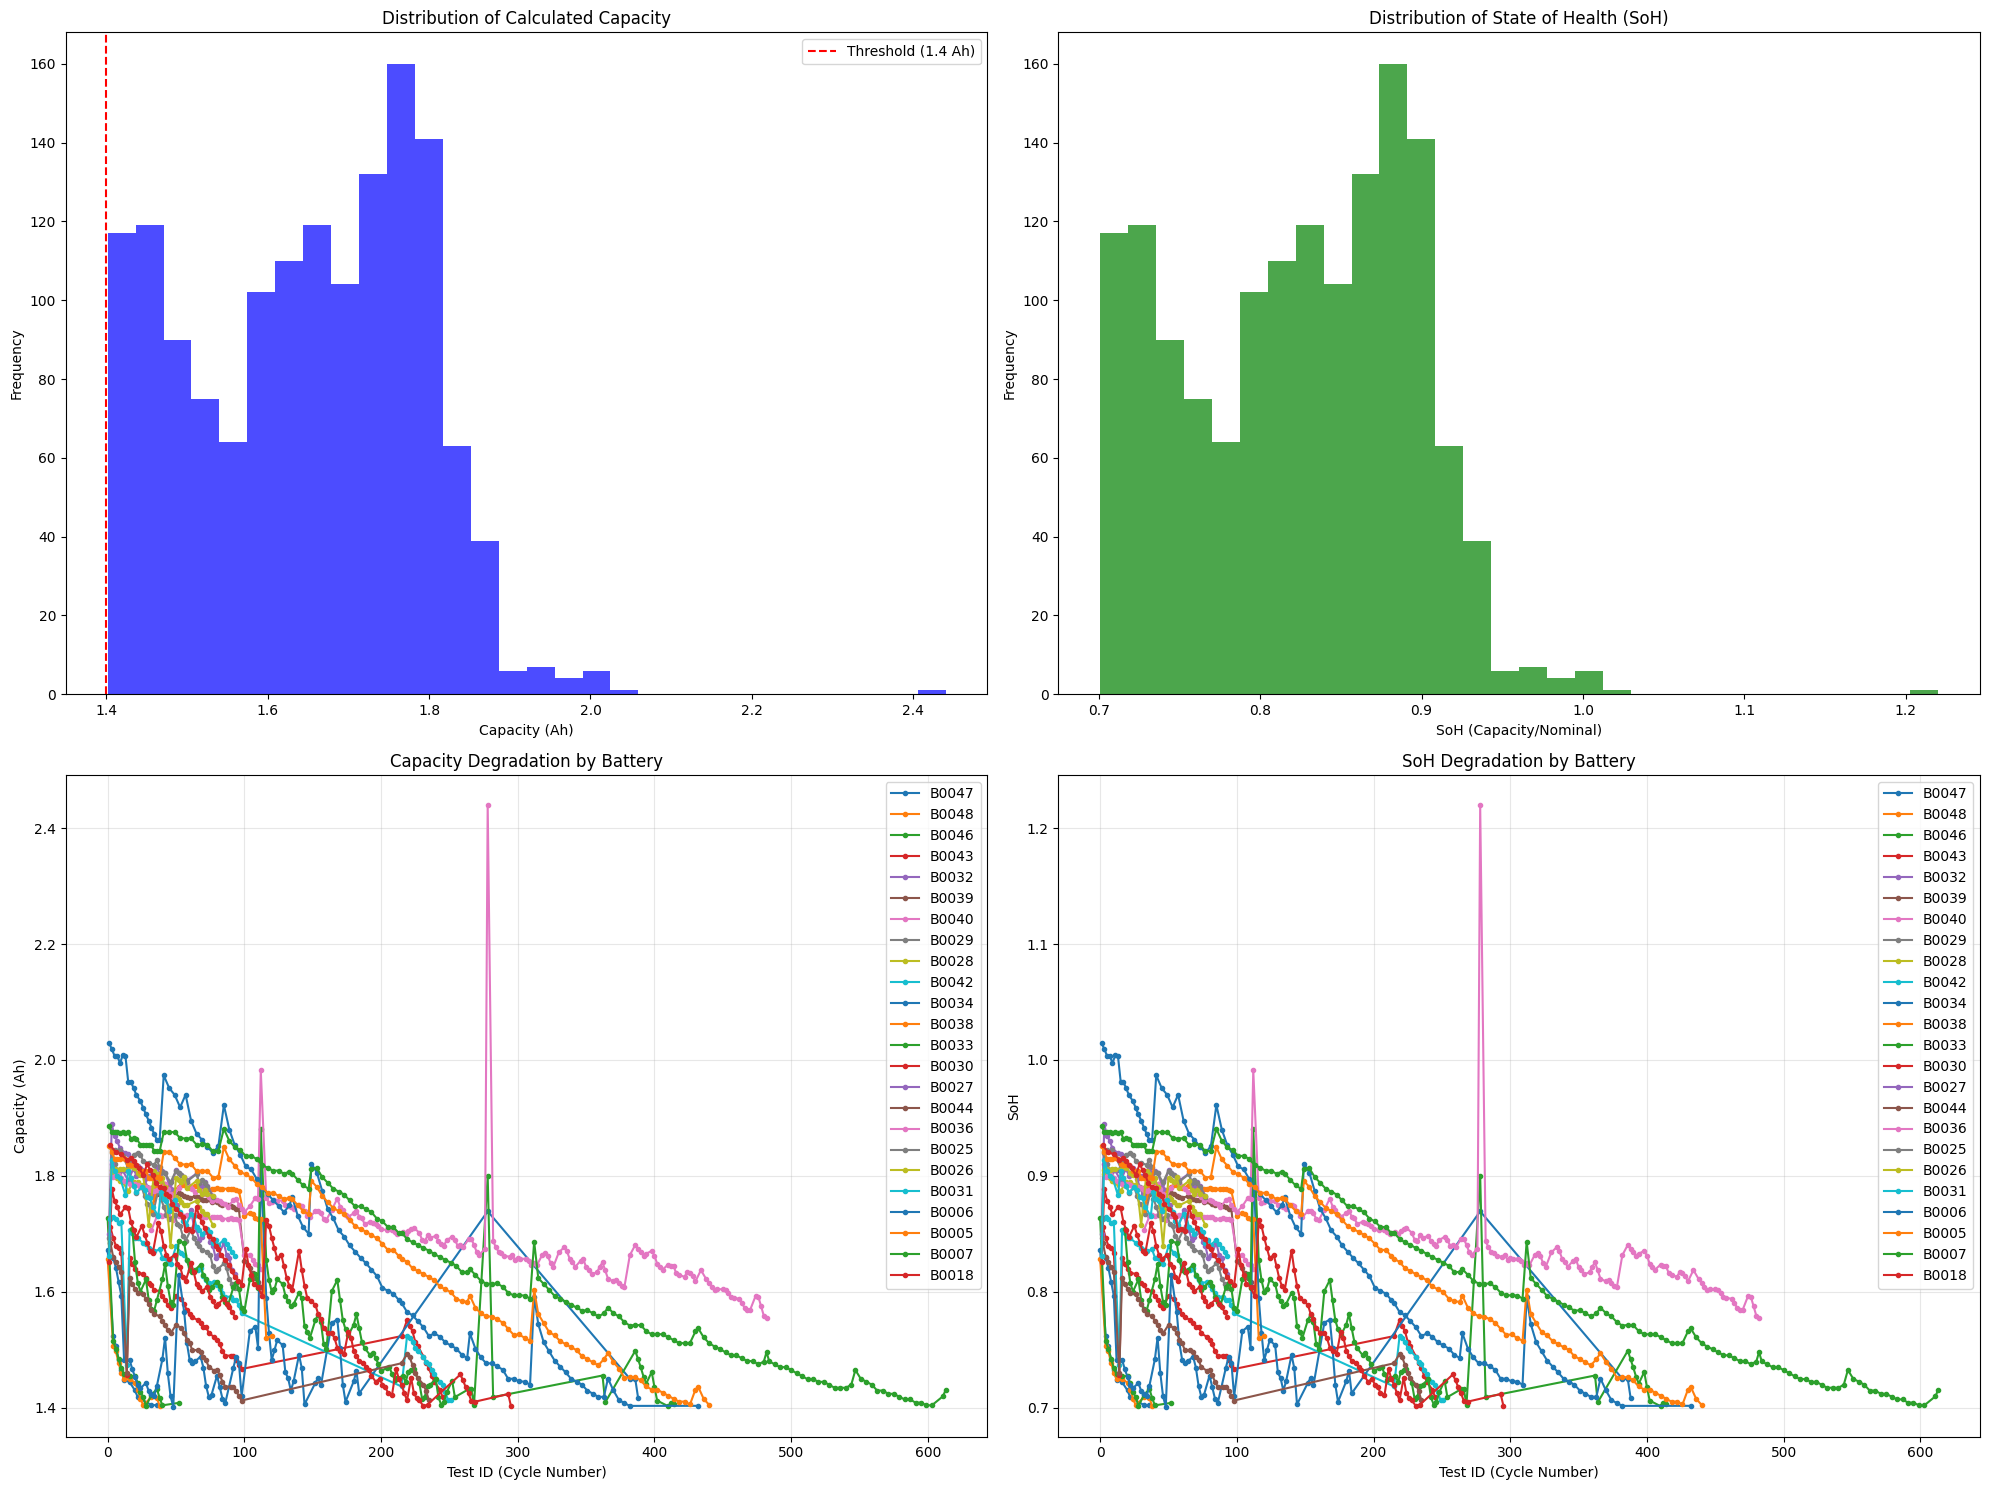


Battery-wise Summary:


calculated_capacity                                     soh  \
                         count    mean     std     min     max    mean   
battery_id                                                               
B0005                      123  1.6548  0.1466  1.4047  1.8510  0.8274   
B0006                      109  1.6829  0.1978  1.4029  2.0292  0.8415   
B0007                      167  1.6428  0.1594  1.4038  1.8853  0.8214   
B0018                      104  1.6040  0.1377  1.4025  1.8526  0.8020   
B0025                       28  1.8129  0.0224  1.7639  1.8450  0.9065   
B0026                       27  1.7869  0.0304  1.6782  1.8137  0.8935   
B0027                       28  1.8012  0.0131  1.7659  1.8197  0.9006   
B0028                       28  1.7678  0.0232  1.7151  1.8024  0.8839   
B0029                       40  1.7206  0.0643  1.6062  1.8397  0.8603   
B0030                       40  1.6558  0.0612  1.5571  1.7768  0.8279   
B0031                       40  1.7377  0.0454  1.6612  1.8280  0.8688   
B0032                       40  1.7490  0.0688  1.6300  1.8887  0.8745   
B0033                      115  1.5407  0.0913  1.4024  1.8813  0.7703   
B0034                       71  1.4857  0.0773  1.4016  1.8168  0.7428   
B0036                      196  1.6994  0.0839  1.5547  2.4402  0.8497   
B0038                       35  1.7551  0.0616  1.5193  1.7852  0.8775   
B0039                       33  1.7350  0.0519  1.6087  1.7704  0.8675   
B0040                       33  1.7146  0.0303  1.6390  1.7330  0.8573   
B0042                       57  1.5974  0.0948  1.4124  1.7290  0.7987   
B0043                       54  1.5538  0.0725  1.4181  1.7114  0.7769   
B0044                       50  1.5173  0.0734  1.4122  1.6843  0.7586   
B0046                       17  1.4607  0.0762  1.4025  1.7264  0.7303   
B0047                       11  1.4724  0.0771  1.4041  1.6727  0.7362   
B0048                       14  1.4591  0.0655  1.4026  1.6565  0.7296   

                                    
               std     min     max  
battery_id                          
B0005       0.0733  0.7023  0.9255  
B0006       0.0989  0.7014  1.0146  
B0007       0.0797  0.7019  0.9427  
B0018       0.0688  0.7012  0.9263  
B0025       0.0112  0.8819  0.9225  
B0026       0.0152  0.8391  0.9069  
B0027       0.0066  0.8830  0.9099  
B0028       0.0116  0.8575  0.9012  
B0029       0.0322  0.8031  0.9199  
B0030       0.0306  0.7786  0.8884  
B0031       0.0227  0.8306  0.9140  
B0032       0.0344  0.8150  0.9444  
B0033       0.0456  0.7012  0.9406  
B0034       0.0386  0.7008  0.9084  
B0036       0.0419  0.7774  1.2201  
B0038       0.0308  0.7596  0.8926  
B0039       0.0259  0.8043  0.8852  
B0040       0.0151  0.8195  0.8665  
B0042       0.0474  0.7062  0.8645  
B0043       0.0362  0.7091  0.8557  
B0044       0.0367  0.7061  0.8422  
B0046       0.0381  0.7013  0.8632  
B0047       0.0386  0.7021  0.8363  
B0048       0.0327  0.7013  0.8283

In [13]:
if not processed_discharge_data.empty:
    # Create visualization for capacity and SoH analysis
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Capacity distribution
    axes[0, 0].hist(processed_discharge_data['calculated_capacity'], bins=30, alpha=0.7, color='blue')
    axes[0, 0].set_title('Distribution of Calculated Capacity')
    axes[0, 0].set_xlabel('Capacity (Ah)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(1.4, color='red', linestyle='--', label='Threshold (1.4 Ah)')
    axes[0, 0].legend()
    
    # SoH distribution
    axes[0, 1].hist(processed_discharge_data['soh'], bins=30, alpha=0.7, color='green')
    axes[0, 1].set_title('Distribution of State of Health (SoH)')
    axes[0, 1].set_xlabel('SoH (Capacity/Nominal)')
    axes[0, 1].set_ylabel('Frequency')
    
    # Battery-wise capacity trend
    for battery in processed_discharge_data['battery_id'].unique():
        battery_data = processed_discharge_data[processed_discharge_data['battery_id'] == battery]
        battery_data_sorted = battery_data.sort_values('test_id')
        axes[1, 0].plot(battery_data_sorted['test_id'], battery_data_sorted['calculated_capacity'], 
                       marker='o', label=battery, markersize=3)
    
    axes[1, 0].set_title('Capacity Degradation by Battery')
    axes[1, 0].set_xlabel('Test ID (Cycle Number)')
    axes[1, 0].set_ylabel('Capacity (Ah)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Battery-wise SoH trend
    for battery in processed_discharge_data['battery_id'].unique():
        battery_data = processed_discharge_data[processed_discharge_data['battery_id'] == battery]
        battery_data_sorted = battery_data.sort_values('test_id')
        axes[1, 1].plot(battery_data_sorted['test_id'], battery_data_sorted['soh'], 
                       marker='o', label=battery, markersize=3)
    
    axes[1, 1].set_title('SoH Degradation by Battery')
    axes[1, 1].set_xlabel('Test ID (Cycle Number)')
    axes[1, 1].set_ylabel('SoH')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics by battery
    print("\nBattery-wise Summary:")
    battery_summary = processed_discharge_data.groupby('battery_id').agg({
        'calculated_capacity': ['count', 'mean', 'std', 'min', 'max'],
        'soh': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    display(battery_summary)